Name : Diksha Parulekar.
Roll no. : 23102A0068.
Subject : R programming assignment 7


## 1. Problem Statement

An e-commerce company wants to better understand its customers and improve its marketing decisions. Using historical online retail transaction data, develop a machine-learning-based analytics solution that **(a)** identifies meaningful customer segments and **(b)** predicts whether a customer belongs to a high-value customer category.

**Tasks covered in this notebook**

1. Data preprocessing and customer-level feature engineering (RFM, average transaction value, quantity, purchase frequency)
2. Elbow Method for choosing the number of clusters
3. K-Means customer segmentation
4. Hierarchical clustering and dendrogram
5. Silhouette Score and comparison of clustering results
6. PCA-based 2D visualisation of segments
7. Cluster-wise customer profiling and interpretation
8. Random Forest and SVM models for high-value customer prediction
9. Performance comparison: Accuracy, Precision, Recall, F1-Score, ROC-AUC, Confusion Matrix
10. Feature importance analysis
11. Interactive 3D visualisation with Plotly
12. Segment-wise targeted marketing recommendations

## 2. Dataset Description

**Source:** UCI Machine Learning Repository, *Online Retail* dataset (541,909 transactions from a UK-based online retailer, 01-Dec-2010 to 09-Dec-2011).

| Attribute | Description |
|---|---|
| InvoiceNo | Invoice number (a leading **C** marks a cancellation) |
| StockCode | Product code |
| Description | Product name |
| Quantity | Units per transaction line (negative for cancellations/returns) |
| InvoiceDate | Date and time of the invoice |
| UnitPrice | Price per unit in sterling |
| CustomerID | Unique customer identifier (many values are missing) |
| Country | Customer's country |

## 3. Environment Setup

In [1]:
# ---- Install only what is missing (uses fast Linux binaries when available) ----
options(timeout = 900, warn = 1, scipen = 999)

# Faster binary installs on Colab (falls back to the default CRAN mirror on any problem)
repo <- "https://cloud.r-project.org"
try({
  codename <- sub("VERSION_CODENAME=", "", grep("^VERSION_CODENAME=", readLines("/etc/os-release"), value = TRUE))
  if (length(codename) == 1 && nzchar(codename)) {
    repo <- paste0("https://packagemanager.posit.co/cran/__linux__/", codename, "/latest")
    options(HTTPUserAgent = sprintf("R/%s R (%s)", getRversion(),
            paste(getRversion(), R.version["platform"], R.version["arch"], R.version["os"])))
  }
}, silent = TRUE)
options(repos = c(CRAN = repo))

pkgs <- c("readxl", "dplyr", "ggplot2", "cluster", "randomForest", "e1071", "plotly", "htmlwidgets")
missing_pkgs <- pkgs[!vapply(pkgs, requireNamespace, logical(1), quietly = TRUE)]
if (length(missing_pkgs) > 0) {
  message("Installing: ", paste(missing_pkgs, collapse = ", "))
  install.packages(missing_pkgs, quiet = TRUE)
  # if the fast mirror failed, retry once with the standard CRAN mirror
  still_missing <- missing_pkgs[!vapply(missing_pkgs, requireNamespace, logical(1), quietly = TRUE)]
  if (length(still_missing) > 0) install.packages(still_missing, repos = "https://cloud.r-project.org", quiet = TRUE)
}

# Pandoc is needed to embed Plotly charts in the notebook output (Section 15)
if (Sys.which("pandoc") == "") {
  try(system("apt-get update -qq > /dev/null 2>&1; apt-get install -y -qq pandoc > /dev/null 2>&1"), silent = TRUE)
}

suppressPackageStartupMessages({
  library(dplyr)
  library(ggplot2)
})

options(repr.plot.width = 10, repr.plot.height = 6)
theme_set(theme_minimal(base_size = 13))
set.seed(42)

cat("Setup complete. R version:", as.character(getRversion()), "\n")

Installing: randomForest, e1071, plotly

also installing the dependencies ‘lazyeval’, ‘proxy’, ‘crosstalk’




Setup complete. R version: 4.6.1 


## 4. Data Loading

In [2]:
# ---- Load the UCI Online Retail dataset (with an automatic synthetic fallback) ----
dir.create("data", showWarnings = FALSE)

uci_urls <- c(
  "https://archive.ics.uci.edu/static/public/352/online+retail.zip",
  "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
)
needed_cols <- c("InvoiceNo", "StockCode", "Quantity", "InvoiceDate", "UnitPrice", "CustomerID")

read_retail_xlsx <- function(path) {
  d <- as.data.frame(readxl::read_excel(path))
  if (!all(needed_cols %in% names(d))) stop("Unexpected file schema")
  d
}

load_uci <- function() {
  existing <- list.files("data", pattern = "\\.xlsx$", full.names = TRUE)
  if (length(existing) > 0) {
    d <- tryCatch(read_retail_xlsx(existing[1]), error = function(e) NULL)
    if (!is.null(d)) return(d)
  }
  for (u in uci_urls) {
    d <- tryCatch({
      is_zip <- grepl("zip$", u)
      dest <- if (is_zip) "data/online_retail.zip" else "data/Online_Retail.xlsx"
      download.file(u, dest, mode = "wb", quiet = TRUE)
      if (is_zip) unzip(dest, exdir = "data")
      xl <- list.files("data", pattern = "\\.xlsx$", full.names = TRUE)[1]
      if (is.na(xl)) stop("xlsx file not found after download")
      read_retail_xlsx(xl)
    }, error = function(e) { message("Source failed (", u, "): ", conditionMessage(e)); NULL })
    if (!is.null(d)) return(d)
  }
  NULL
}

# ---- Synthetic fallback with the SAME schema as the UCI dataset ----
make_synthetic_retail <- function(n_customers = 3000, seed = 42) {
  set.seed(seed)
  type <- sample(1:4, n_customers, replace = TRUE, prob = c(0.15, 0.30, 0.30, 0.25))
  cust_id <- 12000 + seq_len(n_customers)
  country <- sample(c("United Kingdom", "Germany", "France", "EIRE", "Spain"),
                    n_customers, replace = TRUE, prob = c(0.85, 0.05, 0.04, 0.03, 0.03))
  n_inv <- integer(n_customers)
  n_inv[type == 1] <- 8L + rpois(sum(type == 1), 10)
  n_inv[type == 2] <- 3L + rpois(sum(type == 2), 3)
  n_inv[type == 3] <- 1L + rpois(sum(type == 3), 1)
  n_inv[type == 4] <- 1L + rpois(sum(type == 4), 0.3)
  lo <- c(0.00, 0.10, 0.20, 0.00)[type]
  hi <- c(1.00, 1.00, 0.90, 0.40)[type]
  line_lambda <- c(14, 8, 5, 3)[type]
  qty_mult <- c(3, 1.5, 1, 1)[type]

  start <- as.POSIXct("2010-12-01 08:00:00", tz = "UTC")
  inv_cust <- rep(seq_len(n_customers), n_inv)
  n_invoices <- length(inv_cust)
  frac <- lo[inv_cust] + (hi[inv_cust] - lo[inv_cust]) * runif(n_invoices)
  inv_date <- start + frac * 373 * 86400
  inv_no <- as.character(540000 + seq_len(n_invoices))
  n_lines <- 1L + rpois(n_invoices, line_lambda[inv_cust])
  line_inv <- rep(seq_len(n_invoices), n_lines)
  nl <- length(line_inv)

  qty <- sample(c(1, 2, 3, 4, 6, 8, 12, 24), nl, replace = TRUE,
                prob = c(.20, .15, .10, .15, .15, .10, .10, .05))
  qty <- pmax(1, round(qty * qty_mult[inv_cust[line_inv]]))
  price <- round(pmax(0.1, exp(rnorm(nl, log(2.5), 0.7))), 2)
  code_id <- sample(1000, nl, replace = TRUE)

  is_cancel <- (runif(n_invoices) < 0.03)[line_inv]
  is_guest  <- (runif(n_invoices) < 0.08)[line_inv]
  inv_str <- ifelse(is_cancel, paste0("C", inv_no[line_inv]), inv_no[line_inv])
  qty <- ifelse(is_cancel, -qty, qty)
  cid <- ifelse(is_guest, NA_real_, cust_id[inv_cust[line_inv]])

  out <- data.frame(
    InvoiceNo   = inv_str,
    StockCode   = sprintf("P%04d", code_id),
    Description = paste("PRODUCT", code_id),
    Quantity    = qty,
    InvoiceDate = inv_date[line_inv],
    UnitPrice   = price,
    CustomerID  = cid,
    Country     = country[inv_cust[line_inv]],
    stringsAsFactors = FALSE
  )
  # a few extreme outliers and bad price records
  bad <- sample(nrow(out), 8)
  out$Quantity[bad[1:5]]  <- sample(4000:9000, 5)
  out$UnitPrice[bad[6:8]] <- 0
  out[order(out$InvoiceDate), ]
}

raw <- load_uci()
if (is.null(raw)) {
  message("UCI download unavailable -> using synthetic fallback dataset with the same schema.")
  raw <- make_synthetic_retail()
  data_source <- "Synthetic fallback (UCI Online Retail schema)"
} else {
  data_source <- "UCI Online Retail (real data)"
}
cat("Data source :", data_source, "\n")
cat("Rows x Cols :", nrow(raw), "x", ncol(raw), "\n")
head(raw)

Data source : UCI Online Retail (real data) 
Rows x Cols : 541909 x 8 


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
,<chr>,<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<chr>
1,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
2,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
3,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
4,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
5,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
6,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom


## 5. Exploratory Overview of the Raw Data

In [3]:
raw$InvoiceNo   <- as.character(raw$InvoiceNo)
raw$InvoiceDate <- as.POSIXct(raw$InvoiceDate, tz = "UTC")

cat("---- Structure ----\n")
str(raw)

cat("\n---- Missing values per column ----\n")
miss <- data.frame(Column = names(raw),
                   Missing = colSums(is.na(raw)),
                   Percent = round(100 * colSums(is.na(raw)) / nrow(raw), 2),
                   row.names = NULL)
print(miss)

cat("\n---- Data quality indicators ----\n")
n_cancel <- sum(startsWith(raw$InvoiceNo, "C"))
cat("Cancelled-invoice lines   :", n_cancel, sprintf("(%.2f%%)\n", 100 * n_cancel / nrow(raw)))
cat("Lines with Quantity <= 0  :", sum(raw$Quantity <= 0, na.rm = TRUE), "\n")
cat("Lines with UnitPrice <= 0 :", sum(raw$UnitPrice <= 0, na.rm = TRUE), "\n")
cat("Date range                :", format(min(raw$InvoiceDate)), "to", format(max(raw$InvoiceDate)), "\n")
cat("Unique invoices           :", n_distinct(raw$InvoiceNo), "\n")
cat("Unique customers          :", n_distinct(raw$CustomerID[!is.na(raw$CustomerID)]), "\n")
cat("Countries                 :", n_distinct(raw$Country), "\n")

summary(raw[, c("Quantity", "UnitPrice")])

---- Structure ----
'data.frame':	541909 obs. of  8 variables:
 $ InvoiceNo  : chr  "536365" "536365" "536365" "536365" ...
 $ StockCode  : chr  "85123A" "71053" "84406B" "84029G" ...
 $ Description: chr  "WHITE HANGING HEART T-LIGHT HOLDER" "WHITE METAL LANTERN" "CREAM CUPID HEARTS COAT HANGER" "KNITTED UNION FLAG HOT WATER BOTTLE" ...
 $ Quantity   : num  6 6 8 6 6 2 6 6 6 32 ...
 $ InvoiceDate: POSIXct, format: "2010-12-01 08:26:00" "2010-12-01 08:26:00" ...
 $ UnitPrice  : num  2.55 3.39 2.75 3.39 3.39 7.65 4.25 1.85 1.85 1.69 ...
 $ CustomerID : num  17850 17850 17850 17850 17850 ...
 $ Country    : chr  "United Kingdom" "United Kingdom" "United Kingdom" "United Kingdom" ...

---- Missing values per column ----
       Column Missing Percent
1   InvoiceNo       0    0.00
2   StockCode       0    0.00
3 Description    1454    0.27
4    Quantity       0    0.00
5 InvoiceDate       0    0.00
6   UnitPrice       0    0.00
7  CustomerID  135080   24.93
8     Country       0    0.00

---

    Quantity            UnitPrice         
 Min.   :-80995.000   Min.   :-11062.060  
 1st Qu.:     1.000   1st Qu.:     1.250  
 Median :     3.000   Median :     2.080  
 Mean   :     9.552   Mean   :     4.611  
 3rd Qu.:    10.000   3rd Qu.:     4.130  
 Max.   : 80995.000   Max.   : 38970.000  

## 6. Data Preprocessing

Cleaning steps and the reason for each:

| Step | Treatment | Reason |
|---|---|---|
| 1 | Remove exact duplicate rows | Duplicates inflate frequency and spend |
| 2 | Remove rows with missing `CustomerID` | Customer-level analysis needs an identifier |
| 3 | Separate **cancellations** (InvoiceNo starting with "C") | Kept as a per-customer *CancelCount* feature, excluded from spend |
| 4 | Remove lines with `Quantity <= 0` or `UnitPrice <= 0` | Returns, adjustments and free/test items are not genuine sales |

In [4]:
n_start <- nrow(raw)
log_tbl <- data.frame(Step = "Raw data", Rows_Remaining = n_start, Rows_Removed = 0)
add_log <- function(step, df_now, prev) {
  rbind(log_tbl, data.frame(Step = step, Rows_Remaining = nrow(df_now), Rows_Removed = prev - nrow(df_now)))
}

# Step 1: duplicates
prev <- nrow(raw)
df <- distinct(raw)
log_tbl <- add_log("1. Remove duplicate rows", df, prev)

# Step 2: missing CustomerID
prev <- nrow(df)
df <- df[!is.na(df$CustomerID), ]
log_tbl <- add_log("2. Remove missing CustomerID", df, prev)

# Step 3: separate cancellations (kept for the CancelCount feature)
is_cancel <- startsWith(df$InvoiceNo, "C")
cancels <- df[is_cancel, ]
prev <- nrow(df)
df <- df[!is_cancel, ]
log_tbl <- add_log("3. Separate cancellations", df, prev)

# Step 4: invalid quantity / price
prev <- nrow(df)
df <- df[df$Quantity > 0 & df$UnitPrice > 0, ]
log_tbl <- add_log("4. Remove Quantity<=0 or UnitPrice<=0", df, prev)

sales <- df
sales$LineTotal <- sales$Quantity * sales$UnitPrice
sales$InvDay    <- as.Date(sales$InvoiceDate)

print(log_tbl, row.names = FALSE)
cat("\nClean sales lines:", nrow(sales), "| Customers:", n_distinct(sales$CustomerID), "\n")

                                  Step Rows_Remaining Rows_Removed
                              Raw data         541909            0
              1. Remove duplicate rows         536641         5268
          2. Remove missing CustomerID         401604       135037
             3. Separate cancellations         392732         8872
 4. Remove Quantity<=0 or UnitPrice<=0         392692           40

Clean sales lines: 392692 | Customers: 4338 


## 7. Customer-Level Feature Engineering (RFM and More)

| Feature | Definition |
|---|---|
| **Recency** | Days between the customer's last purchase and the snapshot date (day after the last transaction in the data). Lower is better |
| **Frequency** | Number of distinct invoices |
| **Monetary** | Total spend (Quantity × UnitPrice) |
| **AvgTransactionValue** | Monetary ÷ Frequency |
| **TotalQuantity** | Total units purchased |
| **PurchaseFrequency** | Orders per month of customer tenure (Frequency ÷ months between first purchase and snapshot, minimum 1 month) |
| UniqueProducts, TenureDays, CancelCount | Extra behavioural features used by the supervised models |

In [5]:
snapshot_date <- max(sales$InvDay) + 1
cat("Snapshot date:", format(snapshot_date), "\n")

customers <- sales %>%
  group_by(CustomerID) %>%
  summarise(
    Recency        = as.numeric(snapshot_date - max(InvDay)),
    Frequency      = n_distinct(InvoiceNo),
    Monetary       = sum(LineTotal),
    TotalQuantity  = sum(Quantity),
    UniqueProducts = n_distinct(StockCode),
    FirstPurchase  = min(InvDay),
    .groups = "drop"
  ) %>%
  mutate(
    TenureDays          = as.numeric(snapshot_date - FirstPurchase),
    AvgTransactionValue = Monetary / Frequency,
    PurchaseFrequency   = Frequency / pmax(TenureDays / 30, 1)
  )

cancel_tbl <- cancels %>%
  group_by(CustomerID) %>%
  summarise(CancelCount = n_distinct(InvoiceNo), .groups = "drop")

customers <- customers %>%
  left_join(cancel_tbl, by = "CustomerID") %>%
  mutate(CancelCount = ifelse(is.na(CancelCount), 0, CancelCount)) %>%
  select(-FirstPurchase)

customers <- as.data.frame(customers)

cluster_vars <- c("Recency", "Frequency", "Monetary", "AvgTransactionValue",
                  "TotalQuantity", "PurchaseFrequency")
extra_vars   <- c("UniqueProducts", "CancelCount", "TenureDays")

cat("Customers:", nrow(customers), "\n\n")
head(customers)
cat("\n")
print(round(sapply(customers[, c(cluster_vars, extra_vars)], function(x) c(Min = min(x), Median = median(x), Mean = mean(x), Max = max(x))), 2))

Snapshot date: 2011-12-10 
Customers: 4338 



,CustomerID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,TenureDays,AvgTransactionValue,PurchaseFrequency,CancelCount
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,12346,326,1,77183.60,74215,1,326,77183.6000,0.09202454,1
2,12347,3,7,4310.00,2458,103,368,615.7143,0.57065217,0
3,12348,76,4,1797.24,2341,22,359,449.3100,0.33426184,0
4,12349,19,1,1757.55,631,73,19,1757.5500,1.00000000,0
5,12350,311,1,334.40,197,17,311,334.4000,0.09646302,0
6,12352,37,8,2506.04,536,59,297,313.2550,0.80808081,3



       Recency Frequency  Monetary AvgTransactionValue TotalQuantity
Min       1.00      1.00      3.75                3.45          1.00
Median   51.00      2.00    668.57              291.94        378.00
Mean     93.06      4.27   2048.69              417.65       1187.64
Max     374.00    209.00 280206.02            84236.25     196915.00
       PurchaseFrequency UniqueProducts CancelCount TenureDays
Min                 0.08            1.0        0.00       1.00
Median              0.45           35.0        0.00     249.00
Mean                0.63           61.5        0.83     223.83
Max                16.76         1787.0       47.00     374.00


## 8. Outlier Treatment and Feature Scaling

RFM variables are strongly right-skewed (a few very large customers). The treatment pipeline:

1. **Log transform** (`log1p`) to reduce skewness
2. **IQR capping (winsorisation)** at Q1 − 1.5·IQR and Q3 + 1.5·IQR on the log scale, so extreme customers are kept but cannot dominate distances
3. **Z-score standardisation**, so every feature contributes equally to K-Means / Hierarchical clustering

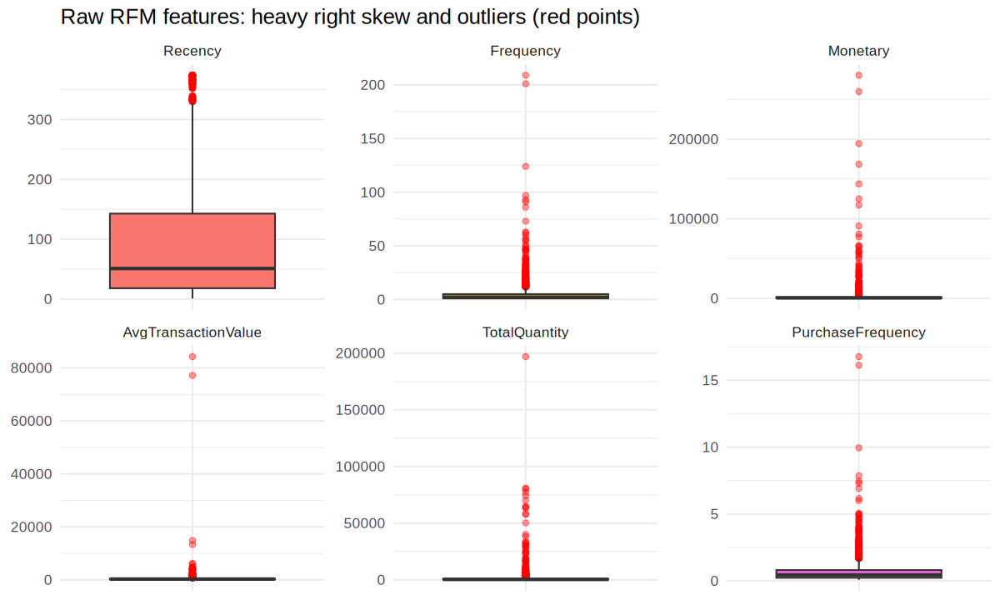

In [6]:
# ---- Before treatment: boxplots of raw features ----
long_raw <- data.frame(
  Feature = rep(cluster_vars, each = nrow(customers)),
  Value   = unname(unlist(customers[cluster_vars]))
)
long_raw$Feature <- factor(long_raw$Feature, levels = cluster_vars)

ggplot(long_raw, aes(x = Feature, y = Value, fill = Feature)) +
  geom_boxplot(outlier.colour = "red", outlier.alpha = 0.4, show.legend = FALSE) +
  facet_wrap(~Feature, scales = "free", nrow = 2) +
  labs(title = "Raw RFM features: heavy right skew and outliers (red points)", x = NULL, y = NULL) +
  theme(axis.text.x = element_blank())

Outliers capped per feature (log scale):
            Recency           Frequency            Monetary AvgTransactionValue 
                  0                  42                  52                 130 
      TotalQuantity   PurchaseFrequency 
                 68                 111 

Scaled feature check (mean ~ 0, sd ~ 1):
     Recency Frequency Monetary AvgTransactionValue TotalQuantity
mean       0         0        0                   0             0
sd         1         1        1                   1             1
     PurchaseFrequency
mean                 0
sd                   1

Correlation between engineered features:
                    Recency Frequency Monetary AvgTransactionValue
Recency                1.00     -0.57    -0.49               -0.13
Frequency             -0.57      1.00     0.81                0.17
Monetary              -0.49      0.81     1.00                0.70
AvgTransactionValue   -0.13      0.17     0.70                1.00
TotalQuantity         -0.49  

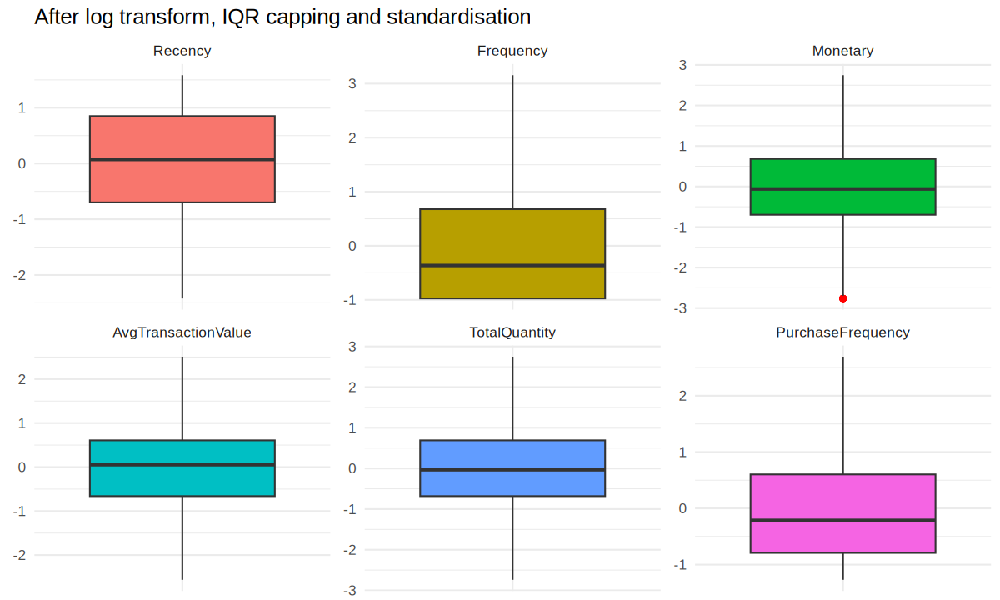

In [7]:
# ---- Treatment functions ----
cap_iqr <- function(x) {
  q <- quantile(x, c(0.25, 0.75), na.rm = TRUE)
  iqr <- q[2] - q[1]
  if (iqr == 0) return(x)
  pmin(pmax(x, q[1] - 1.5 * iqr), q[2] + 1.5 * iqr)
}
zscore <- function(x) {
  s <- sd(x)
  if (is.na(s) || s == 0) return(rep(0, length(x)))
  (x - mean(x)) / s
}

X_log <- as.data.frame(lapply(customers[cluster_vars], log1p))

# number of outliers detected (log scale) per feature
n_out <- sapply(X_log, function(x) sum(x != cap_iqr(x)))
cat("Outliers capped per feature (log scale):\n"); print(n_out)

X_capped <- as.data.frame(lapply(X_log, cap_iqr))
X_scaled <- as.data.frame(lapply(X_capped, zscore))

cat("\nScaled feature check (mean ~ 0, sd ~ 1):\n")
print(round(sapply(X_scaled, function(x) c(mean = mean(x), sd = sd(x))), 3))

# ---- After treatment ----
long_sc <- data.frame(
  Feature = factor(rep(cluster_vars, each = nrow(X_scaled)), levels = cluster_vars),
  Value   = unname(unlist(X_scaled))
)
ggplot(long_sc, aes(x = Feature, y = Value, fill = Feature)) +
  geom_boxplot(outlier.colour = "red", show.legend = FALSE) +
  facet_wrap(~Feature, scales = "free", nrow = 2) +
  labs(title = "After log transform, IQR capping and standardisation", x = NULL, y = NULL) +
  theme(axis.text.x = element_blank())

cat("\nCorrelation between engineered features:\n")
print(round(cor(X_scaled), 2))

## 9. Elbow Method: Choosing the Number of Clusters

The Elbow Method plots the total within-cluster sum of squares (WSS) against *k*. The "elbow" is where adding more clusters stops giving a large reduction in WSS. The elbow is located automatically as the point farthest from the straight line joining the first and last points of the curve, and the average Silhouette Score is plotted alongside as supporting evidence.

Elbow-method k          : 3 
Best-silhouette k       : 2 (avg silhouette = 0.3505 )
Final k used            : 3 


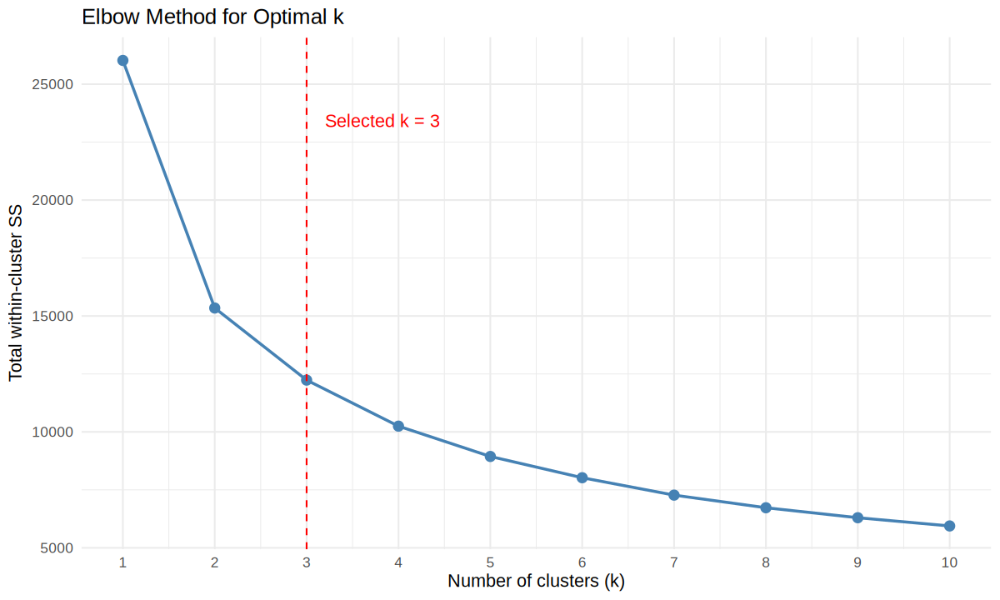

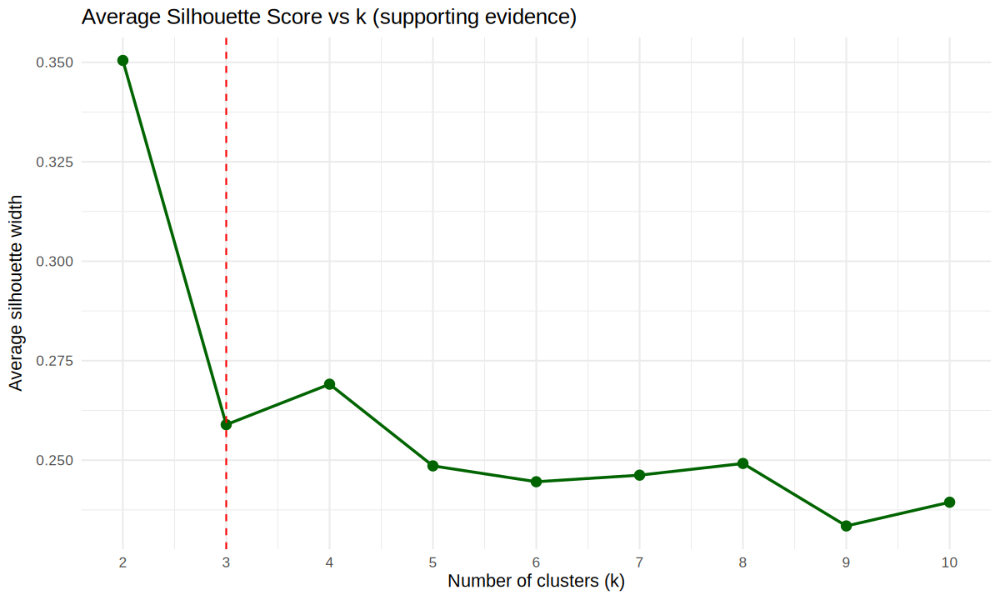

In [8]:
X <- as.matrix(X_scaled)
d_mat <- dist(X)                      # Euclidean distances (reused for silhouette and hierarchical clustering)

set.seed(42)
k_range <- 1:10
wss <- sapply(k_range, function(k) kmeans(X, centers = k, nstart = 25, iter.max = 100)$tot.withinss)

find_elbow <- function(k, w) {
  x <- (k - min(k)) / (max(k) - min(k))
  y <- (w - min(w)) / (max(w) - min(w))
  x1 <- x[1]; y1 <- y[1]; x2 <- x[length(x)]; y2 <- y[length(y)]
  d <- abs((y2 - y1) * x - (x2 - x1) * y + x2 * y1 - y2 * x1) / sqrt((y2 - y1)^2 + (x2 - x1)^2)
  k[which.max(d)]
}
k_elbow <- find_elbow(k_range, wss)

# Average silhouette for k = 2..10
sil_k <- sapply(2:10, function(k) {
  km_k <- kmeans(X, centers = k, nstart = 25, iter.max = 100)
  mean(cluster::silhouette(km_k$cluster, d_mat)[, "sil_width"])
})
k_sil <- (2:10)[which.max(sil_k)]

# Final k: elbow-based, at least 3 so that segments are business-meaningful.
# To force a specific value, set K_OVERRIDE <- 4 (for example) and re-run from here.
K_OVERRIDE <- NULL
k_final <- if (!is.null(K_OVERRIDE)) K_OVERRIDE else max(3, min(k_elbow, 6))

cat("Elbow-method k          :", k_elbow, "\n")
cat("Best-silhouette k       :", k_sil, "(avg silhouette =", round(max(sil_k), 4), ")\n")
cat("Final k used            :", k_final, "\n")

elbow_df <- data.frame(k = k_range, WSS = wss)
ggplot(elbow_df, aes(k, WSS)) +
  geom_line(colour = "steelblue", linewidth = 1) +
  geom_point(size = 3, colour = "steelblue") +
  geom_vline(xintercept = k_final, linetype = "dashed", colour = "red") +
  annotate("text", x = k_final + 0.2, y = max(wss) * 0.9, label = paste("Selected k =", k_final),
           colour = "red", hjust = 0) +
  scale_x_continuous(breaks = k_range) +
  labs(title = "Elbow Method for Optimal k", x = "Number of clusters (k)", y = "Total within-cluster SS")

sil_df <- data.frame(k = 2:10, Silhouette = sil_k)
ggplot(sil_df, aes(k, Silhouette)) +
  geom_line(colour = "darkgreen", linewidth = 1) +
  geom_point(size = 3, colour = "darkgreen") +
  geom_vline(xintercept = k_final, linetype = "dashed", colour = "red") +
  scale_x_continuous(breaks = 2:10) +
  labs(title = "Average Silhouette Score vs k (supporting evidence)", x = "Number of clusters (k)", y = "Average silhouette width")

## 10. K-Means Clustering

K-Means with k = 3 
Cluster sizes:

   1    2    3 
1841  966 1531 

Between-SS / Total-SS: 52.99 %
Average Silhouette Score (K-Means): 0.2589 


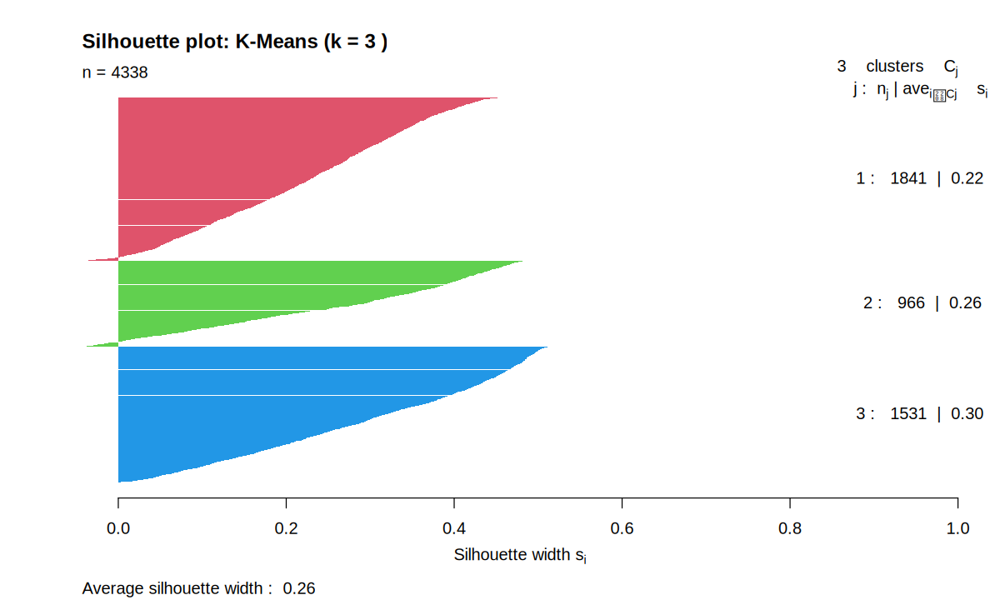

In [9]:
set.seed(42)
km <- kmeans(X, centers = k_final, nstart = 50, iter.max = 200)
customers$KMeans_Cluster <- km$cluster

sil_km <- cluster::silhouette(km$cluster, d_mat)
avg_sil_km <- mean(sil_km[, "sil_width"])

cat("K-Means with k =", k_final, "\n")
cat("Cluster sizes:\n"); print(table(km$cluster))
cat("\nBetween-SS / Total-SS:", round(100 * km$betweenss / km$totss, 2), "%\n")
cat("Average Silhouette Score (K-Means):", round(avg_sil_km, 4), "\n")

plot(sil_km, col = (1:k_final) + 1, border = NA, main = paste("Silhouette plot: K-Means (k =", k_final, ")"))

## 11. Hierarchical Clustering and Dendrogram

Agglomerative clustering with **Ward's method (`ward.D2`)** on the same standardised features. The tree is cut at the same *k* so the two methods can be compared fairly.

Hierarchical cluster sizes:

   1    2    3 
1857 1468 1013 

Average Silhouette Score (Hierarchical): 0.2208 
Cophenetic correlation                  : 0.5351 


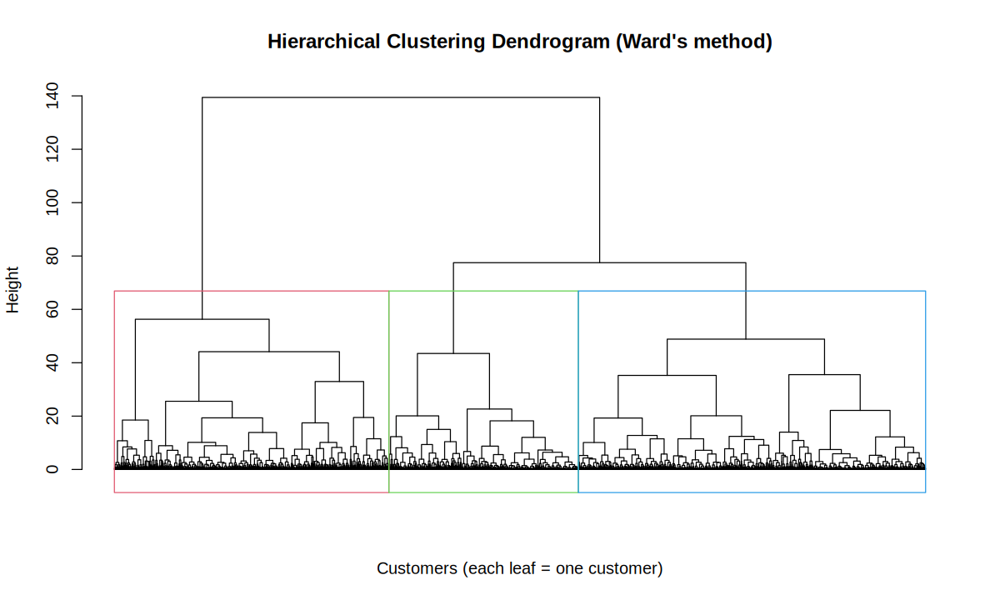

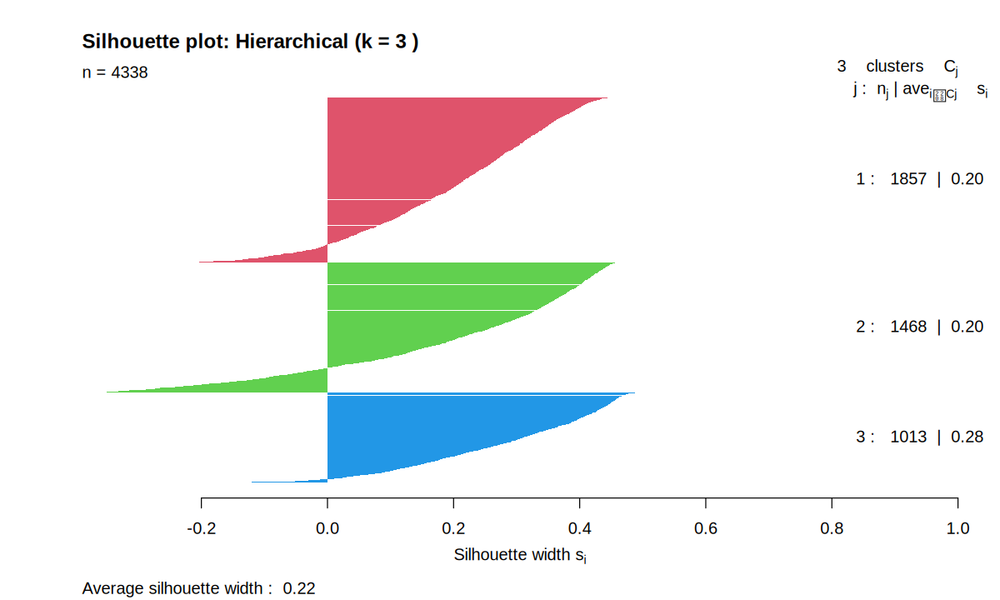

In [10]:
hc <- hclust(d_mat, method = "ward.D2")

plot(hc, labels = FALSE, hang = -1, xlab = "Customers (each leaf = one customer)", sub = "",
     main = "Hierarchical Clustering Dendrogram (Ward's method)")
rect.hclust(hc, k = k_final, border = 2:(k_final + 1))

customers$HC_Cluster <- cutree(hc, k = k_final)

sil_hc <- cluster::silhouette(customers$HC_Cluster, d_mat)
avg_sil_hc <- mean(sil_hc[, "sil_width"])
coph_cor <- cor(cophenetic(hc), d_mat)

cat("Hierarchical cluster sizes:\n"); print(table(customers$HC_Cluster))
cat("\nAverage Silhouette Score (Hierarchical):", round(avg_sil_hc, 4), "\n")
cat("Cophenetic correlation                  :", round(coph_cor, 4), "\n")

plot(sil_hc, col = (1:k_final) + 1, border = NA, main = paste("Silhouette plot: Hierarchical (k =", k_final, ")"))

## 12. Silhouette Score and Comparison of Clustering Results

              Method Clusters Avg_Silhouette Smallest_Cluster Largest_Cluster
             K-Means        3         0.2589              966            1841
 Hierarchical (Ward)        3         0.2208             1013            1857

Adjusted Rand Index (agreement between K-Means and Hierarchical): 0.4226 

Cross-tabulation (rows = K-Means, columns = Hierarchical):
      Hierarchical
KMeans    1    2    3
     1 1318  504   19
     2   11  954    1
     3  528   10  993

Higher silhouette: K-Means -> K-Means is used for profiling and for the supervised models.
(Silhouette interpretation: >0.5 strong, 0.25-0.5 reasonable, <0.25 weak structure.)


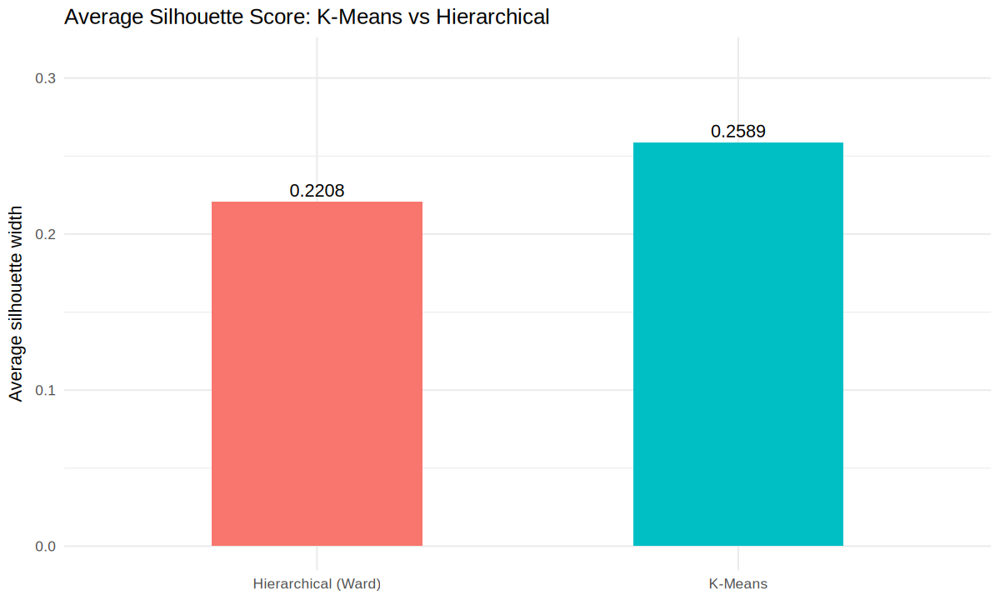

In [11]:
adj_rand <- function(a, b) {
  tab <- table(a, b); n <- sum(tab)
  comb2 <- function(x) sum(x * (x - 1) / 2)
  s_ij <- comb2(tab); s_a <- comb2(rowSums(tab)); s_b <- comb2(colSums(tab))
  expected <- s_a * s_b / (n * (n - 1) / 2)
  (s_ij - expected) / (0.5 * (s_a + s_b) - expected)
}

ari <- adj_rand(customers$KMeans_Cluster, customers$HC_Cluster)

comparison <- data.frame(
  Method = c("K-Means", "Hierarchical (Ward)"),
  Clusters = k_final,
  Avg_Silhouette = round(c(avg_sil_km, avg_sil_hc), 4),
  Smallest_Cluster = c(min(table(customers$KMeans_Cluster)), min(table(customers$HC_Cluster))),
  Largest_Cluster = c(max(table(customers$KMeans_Cluster)), max(table(customers$HC_Cluster)))
)
print(comparison, row.names = FALSE)

cat("\nAdjusted Rand Index (agreement between K-Means and Hierarchical):", round(ari, 4), "\n")
cat("\nCross-tabulation (rows = K-Means, columns = Hierarchical):\n")
print(table(KMeans = customers$KMeans_Cluster, Hierarchical = customers$HC_Cluster))

best_method <- if (avg_sil_km >= avg_sil_hc) "K-Means" else "Hierarchical (Ward)"
cat("\nHigher silhouette:", best_method, "-> K-Means is used for profiling and for the supervised models.\n")
cat("(Silhouette interpretation: >0.5 strong, 0.25-0.5 reasonable, <0.25 weak structure.)\n")

ggplot(comparison, aes(Method, Avg_Silhouette, fill = Method)) +
  geom_col(width = 0.5, show.legend = FALSE) +
  geom_text(aes(label = Avg_Silhouette), vjust = -0.4) +
  labs(title = "Average Silhouette Score: K-Means vs Hierarchical", y = "Average silhouette width", x = NULL) +
  ylim(0, max(comparison$Avg_Silhouette) * 1.2)

## 13. PCA and 2D Visualisation of Customer Segments

  PC Variance_Pct Cumulative_Pct
 PC1        63.16          63.16
 PC2        21.38          84.53
 PC3         9.09          93.63
 PC4         4.53          98.15
 PC5         1.73          99.88
 PC6         0.12         100.00

PCA loadings (first 3 components):
                       PC1    PC2    PC3
Recency             -0.366  0.454 -0.420
Frequency            0.439 -0.183 -0.623
Monetary             0.483  0.255 -0.164
AvgTransactionValue  0.288  0.648  0.503
TotalQuantity        0.472  0.231 -0.163
PurchaseFrequency    0.365 -0.471  0.359


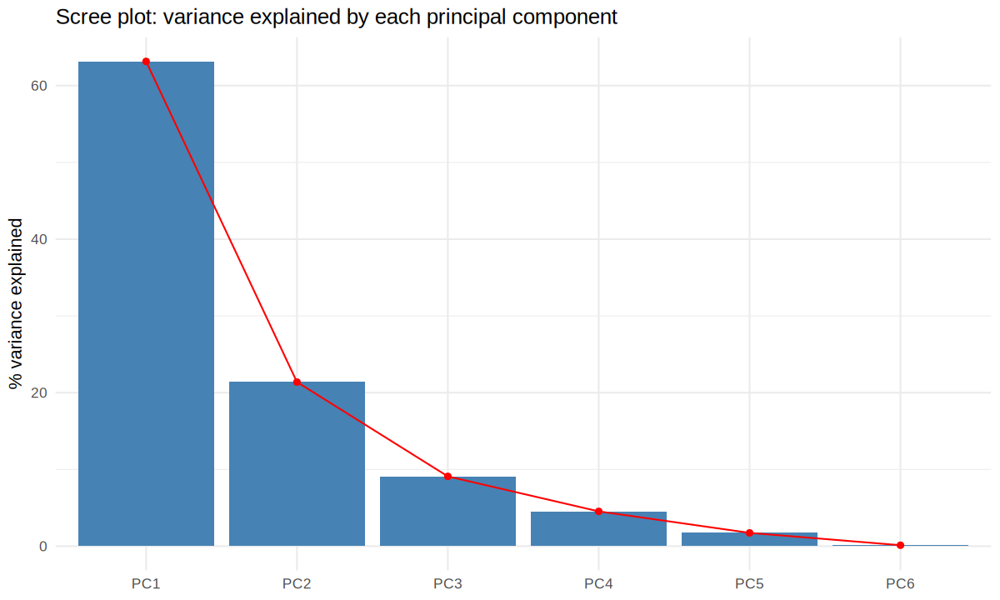

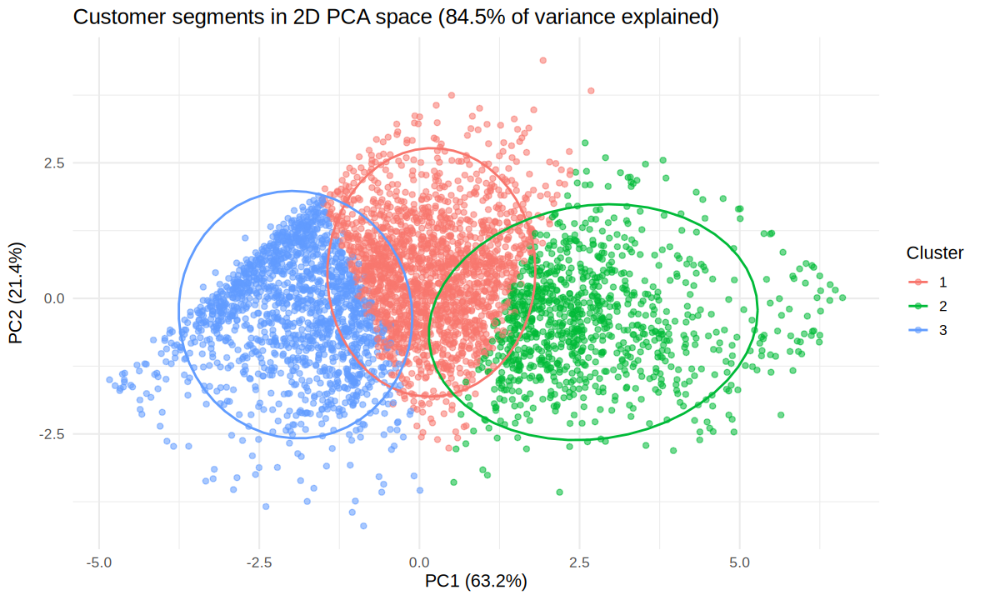

In [12]:
pca <- prcomp(X, center = TRUE, scale. = FALSE)   # X is already standardised

var_exp <- pca$sdev^2 / sum(pca$sdev^2)
pca_tbl <- data.frame(PC = paste0("PC", seq_along(var_exp)),
                      Variance_Pct = round(100 * var_exp, 2),
                      Cumulative_Pct = round(100 * cumsum(var_exp), 2))
print(pca_tbl, row.names = FALSE)

cat("\nPCA loadings (first 3 components):\n")
print(round(pca$rotation[, 1:3], 3))

# Scree plot
scree_df <- data.frame(PC = factor(pca_tbl$PC, levels = pca_tbl$PC), Variance = pca_tbl$Variance_Pct)
ggplot(scree_df, aes(PC, Variance)) +
  geom_col(fill = "steelblue") +
  geom_line(aes(group = 1), colour = "red") + geom_point(colour = "red") +
  labs(title = "Scree plot: variance explained by each principal component", y = "% variance explained", x = NULL)

# 2D projection coloured by K-Means cluster
pc_scores <- data.frame(pca$x[, 1:3])
pc_scores$Cluster <- factor(customers$KMeans_Cluster)

ggplot(pc_scores, aes(PC1, PC2, colour = Cluster)) +
  geom_point(alpha = 0.55, size = 1.6) +
  stat_ellipse(type = "norm", level = 0.9, linewidth = 0.8) +
  labs(title = sprintf("Customer segments in 2D PCA space (%.1f%% of variance explained)", 100 * sum(var_exp[1:2])),
       x = sprintf("PC1 (%.1f%%)", 100 * var_exp[1]), y = sprintf("PC2 (%.1f%%)", 100 * var_exp[2]))

## 14. Cluster-wise Customer Profiling

Profiles are computed on the **original (unscaled)** values so they can be read in business terms. Segments are ranked by average spend and named using simple rules: the top spender is the *Champions (High-Value)* segment, the lowest spender is *Lost / Low-Value*, and middle segments are *Potential Loyalists* (recent buyers) or *At-Risk Customers* (less recent buyers).

                     Segment Customers Pct_Customers Pct_Revenue Avg_Recency
 Champions (High-Value) [C2]       966         22.27       71.08       18.06
    Potential Loyalists [C1]      1841         42.44       24.64       74.60
       Lost / Low-Value [C3]      1531         35.29        4.28      162.58
 Avg_Frequency Avg_Monetary Avg_TransValue Avg_Quantity Avg_PurchFreq
         11.55      6539.56         579.31      3766.65          1.35
          2.77      1189.28         525.74       706.93          0.50
          1.49       248.55         185.66       138.45          0.34


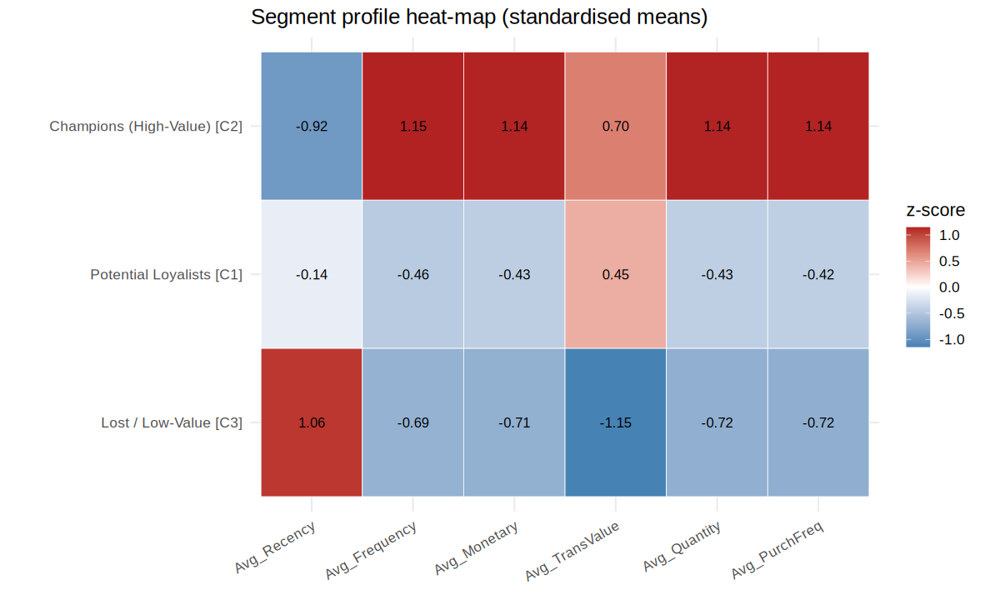

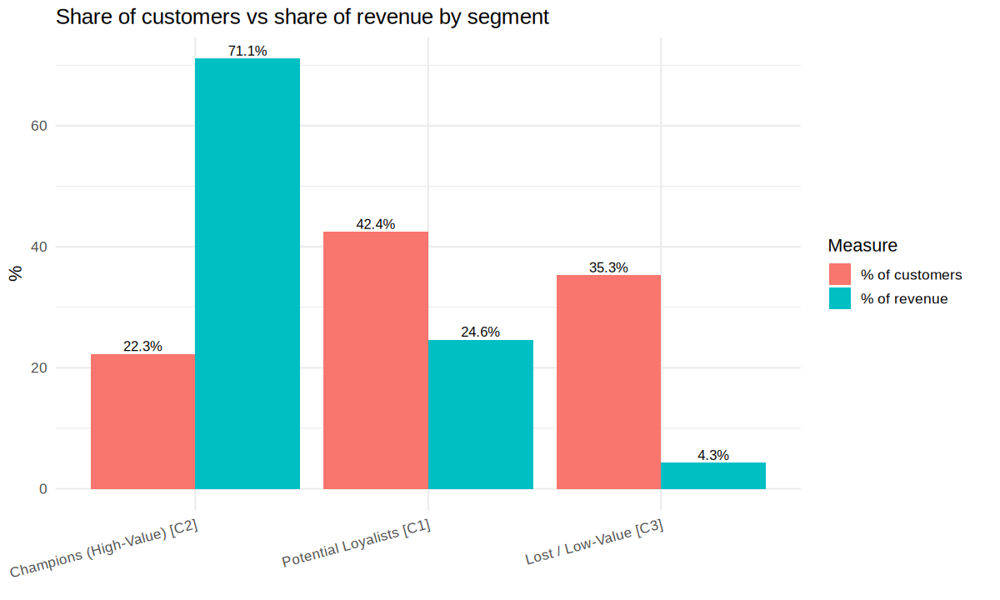

In [13]:
profile <- customers %>%
  group_by(KMeans_Cluster) %>%
  summarise(
    Customers          = n(),
    Avg_Recency        = mean(Recency),
    Avg_Frequency      = mean(Frequency),
    Avg_Monetary       = mean(Monetary),
    Avg_TransValue     = mean(AvgTransactionValue),
    Avg_Quantity       = mean(TotalQuantity),
    Avg_PurchFreq      = mean(PurchaseFrequency),
    Total_Revenue      = sum(Monetary),
    .groups = "drop"
  ) %>%
  mutate(Pct_Customers = 100 * Customers / sum(Customers),
         Pct_Revenue   = 100 * Total_Revenue / sum(Total_Revenue)) %>%
  as.data.frame()

prof <- profile[order(-profile$Avg_Monetary), ]
med_rec <- median(prof$Avg_Recency)
seg_type <- character(nrow(prof))
for (i in seq_len(nrow(prof))) {
  seg_type[i] <- if (i == 1) "Champions (High-Value)"
                 else if (i == nrow(prof)) "Lost / Low-Value"
                 else if (prof$Avg_Recency[i] <= med_rec) "Potential Loyalists"
                 else "At-Risk Customers"
}
prof$Segment_Type <- seg_type
prof$Segment <- paste0(seg_type, " [C", prof$KMeans_Cluster, "]")

customers$Segment_Type <- prof$Segment_Type[match(customers$KMeans_Cluster, prof$KMeans_Cluster)]
customers$Segment      <- prof$Segment[match(customers$KMeans_Cluster, prof$KMeans_Cluster)]
customers$Segment      <- factor(customers$Segment, levels = prof$Segment)

show_prof <- prof
num_cols <- sapply(show_prof, is.numeric)
show_prof[num_cols] <- lapply(show_prof[num_cols], round, 2)
print(show_prof[, c("Segment", "Customers", "Pct_Customers", "Pct_Revenue", "Avg_Recency", "Avg_Frequency",
                    "Avg_Monetary", "Avg_TransValue", "Avg_Quantity", "Avg_PurchFreq")], row.names = FALSE)

# Heat-map of standardised segment means (red = above average, blue = below average)
heat_vars <- c("Avg_Recency", "Avg_Frequency", "Avg_Monetary", "Avg_TransValue", "Avg_Quantity", "Avg_PurchFreq")
heat_z <- as.data.frame(scale(prof[, heat_vars]))
heat_z[is.na(heat_z)] <- 0
heat_long <- data.frame(
  Segment = factor(rep(prof$Segment, times = length(heat_vars)), levels = rev(prof$Segment)),
  Metric  = factor(rep(heat_vars, each = nrow(prof)), levels = heat_vars),
  Z       = unname(unlist(heat_z))
)
ggplot(heat_long, aes(Metric, Segment, fill = Z)) +
  geom_tile(colour = "white") +
  geom_text(aes(label = sprintf("%.2f", Z)), size = 3.5) +
  scale_fill_gradient2(low = "steelblue", mid = "white", high = "firebrick", midpoint = 0) +
  labs(title = "Segment profile heat-map (standardised means)", x = NULL, y = NULL, fill = "z-score") +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

# Customers and revenue share
share_long <- data.frame(
  Segment = factor(rep(prof$Segment, 2), levels = prof$Segment),
  Measure = rep(c("% of customers", "% of revenue"), each = nrow(prof)),
  Percent = c(prof$Pct_Customers, prof$Pct_Revenue)
)
ggplot(share_long, aes(Segment, Percent, fill = Measure)) +
  geom_col(position = "dodge") +
  geom_text(aes(label = sprintf("%.1f%%", Percent)), position = position_dodge(width = 0.9), vjust = -0.3, size = 3.5) +
  labs(title = "Share of customers vs share of revenue by segment", x = NULL, y = "%") +
  theme(axis.text.x = element_text(angle = 15, hjust = 1))

## 15. Interactive 3D Visualisation of Customer Clusters (Plotly)

Two interactive views: (1) the first three principal components, (2) log-scaled Recency, Frequency and Monetary value. Rotate, zoom, and hover over points; click legend entries to toggle segments.

In [14]:
# Helper: embed a Plotly widget in Colab's R output (needs pandoc, installed in Section 3)
show_widget <- function(p, file) {
  shown <- FALSE
  try({
    htmlwidgets::saveWidget(p, file, selfcontained = TRUE)
    if (requireNamespace("IRdisplay", quietly = TRUE)) {
      IRdisplay::display_html(file = file)
      shown <- TRUE
    }
  }, silent = TRUE)
  if (!shown) {
    cat("(Inline display unavailable - the interactive chart was saved to", file, "; open it from the Files panel.)\n")
    try(print(p), silent = TRUE)
  }
  invisible(p)
}

hover_txt <- paste0("Customer ", customers$CustomerID,
                    "<br>Segment: ", customers$Segment,
                    "<br>Recency: ", customers$Recency, " days",
                    "<br>Frequency: ", customers$Frequency, " orders",
                    "<br>Monetary: ", round(customers$Monetary, 2))

# ---- 3D plot 1: PCA space ----
df3d <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], PC3 = pca$x[, 3],
                   Segment = customers$Segment, hover = hover_txt)

p3d_pca <- plotly::plot_ly(
  data = df3d, x = ~PC1, y = ~PC2, z = ~PC3, color = ~Segment, colors = "Set1",
  type = "scatter3d", mode = "markers", text = ~hover, hoverinfo = "text",
  marker = list(size = 3, opacity = 0.75)
)
p3d_pca <- plotly::layout(p3d_pca,
  title = "Customer segments: 3D PCA projection",
  scene = list(xaxis = list(title = sprintf("PC1 (%.1f%%)", 100 * var_exp[1])),
               yaxis = list(title = sprintf("PC2 (%.1f%%)", 100 * var_exp[2])),
               zaxis = list(title = sprintf("PC3 (%.1f%%)", 100 * var_exp[3]))))
show_widget(p3d_pca, "plotly_pca_3d.html")

<!DOCTYPE html>
 
 
 
 plotly

In [15]:
# ---- 3D plot 2: log-scaled Recency / Frequency / Monetary ----
df_rfm <- data.frame(
  logRecency   = log1p(customers$Recency),
  logFrequency = log1p(customers$Frequency),
  logMonetary  = log1p(customers$Monetary),
  Segment = customers$Segment, hover = hover_txt
)

p3d_rfm <- plotly::plot_ly(
  data = df_rfm, x = ~logRecency, y = ~logFrequency, z = ~logMonetary, color = ~Segment, colors = "Set1",
  type = "scatter3d", mode = "markers", text = ~hover, hoverinfo = "text",
  marker = list(size = 3, opacity = 0.75)
)
p3d_rfm <- plotly::layout(p3d_rfm,
  title = "Customer segments in RFM space (log scale)",
  scene = list(xaxis = list(title = "log(1 + Recency)"),
               yaxis = list(title = "log(1 + Frequency)"),
               zaxis = list(title = "log(1 + Monetary)")))
show_widget(p3d_rfm, "plotly_rfm_3d.html")

<!DOCTYPE html>
 
 
 
 plotly

## 16. Defining the High-Value Segment and Preparing Data for Supervised Learning

The segment with the highest average spend (*Champions*) is defined as the **high-value** class. Each customer gets a binary label (`High` vs `Other`).

> **Note on interpretation:** the label is derived from clusters built on RFM-type features, so the classifiers can learn it very well. The supervised models therefore act as a *scalable scoring rule* that can assign new customers to the high-value segment without re-running the clustering. Three extra behavioural features (UniqueProducts, CancelCount, TenureDays) that were not used for clustering are included as well.

In [16]:
hv_cluster <- prof$KMeans_Cluster[1]
hv_name    <- prof$Segment[1]
cat("High-value segment:", hv_name, "(K-Means cluster", hv_cluster, ")\n")

y_all <- factor(ifelse(customers$KMeans_Cluster == hv_cluster, "High", "Other"), levels = c("Other", "High"))
customers$HighValue <- y_all
cat("\nClass distribution:\n"); print(table(y_all)); print(round(100 * prop.table(table(y_all)), 2))

# Predictors: scaled clustering features + scaled extra features (log1p + z-score)
extra_scaled <- as.data.frame(lapply(customers[extra_vars], function(x) zscore(log1p(x))))
model_x <- cbind(X_scaled, extra_scaled)

# Stratified 80/20 train-test split
set.seed(123)
split_idx <- function(idx, p = 0.8) idx[sample.int(length(idx), floor(p * length(idx)))]
train_id <- c(split_idx(which(y_all == "High")), split_idx(which(y_all == "Other")))
train_x <- model_x[train_id, ];  train_y <- y_all[train_id]
test_x  <- model_x[-train_id, ]; test_y  <- y_all[-train_id]

cat("\nTraining rows:", nrow(train_x), "| Test rows:", nrow(test_x), "\n")
cat("Predictors used:", paste(names(model_x), collapse = ", "), "\n")

High-value segment: Champions (High-Value) [C2] (K-Means cluster 2 )

Class distribution:
y_all
Other  High 
 3372   966 
y_all
Other  High 
77.73 22.27 

Training rows: 3469 | Test rows: 869 
Predictors used: Recency, Frequency, Monetary, AvgTransactionValue, TotalQuantity, PurchaseFrequency, UniqueProducts, CancelCount, TenureDays 


## 17. Model 1: Random Forest

In [17]:
set.seed(123)
rf_model <- randomForest::randomForest(x = train_x, y = train_y, ntree = 500, importance = TRUE)
print(rf_model)

rf_prob <- predict(rf_model, test_x, type = "prob")[, "High"]
rf_pred <- factor(as.character(predict(rf_model, test_x)), levels = levels(y_all))


Call:
 randomForest(x = train_x, y = train_y, ntree = 500, importance = TRUE) 
               Type of random forest: classification
                     Number of trees: 500
No. of variables tried at each split: 3

        OOB estimate of  error rate: 1.96%
Confusion matrix:
      Other High class.error
Other  2668   29  0.01075269
High     39  733  0.05051813


## 18. Model 2: Support Vector Machine (RBF kernel)

In [18]:
# Small grid search (3-fold CV) for cost and gamma
set.seed(123)
svm_tune <- e1071::tune.svm(x = train_x, y = train_y, kernel = "radial",
                            cost = c(1, 10), gamma = c(0.05, 0.2),
                            tunecontrol = e1071::tune.control(cross = 3))
best_cost  <- svm_tune$best.parameters$cost
best_gamma <- svm_tune$best.parameters$gamma
cat("Best SVM parameters -> cost:", best_cost, "| gamma:", best_gamma, "\n")

# Class weights to account for class imbalance
cw <- c(Other = 1, High = as.numeric(sum(train_y == "Other") / sum(train_y == "High")))

svm_model <- e1071::svm(x = train_x, y = train_y, kernel = "radial", cost = best_cost, gamma = best_gamma,
                        probability = TRUE, class.weights = cw, scale = FALSE)
print(svm_model)

svm_raw  <- predict(svm_model, test_x, probability = TRUE)
svm_pred <- factor(as.character(svm_raw), levels = levels(y_all))
svm_prob <- attr(svm_raw, "probabilities")[, "High"]

Best SVM parameters -> cost: 1 | gamma: 0.05 

Call:
svm.default(x = train_x, y = train_y, scale = FALSE, kernel = "radial", 
    gamma = best_gamma, cost = best_cost, class.weights = cw, probability = TRUE)


Parameters:
   SVM-Type:  C-classification 
 SVM-Kernel:  radial 
       cost:  1 

Number of Support Vectors:  273



## 19. Model Evaluation and Comparison

Metrics (positive class = **High**): Accuracy, Precision, Recall, F1-Score, ROC-AUC, plus the Confusion Matrix and ROC curves.

In [19]:
auc_score <- function(truth, score) {
  pos <- truth == "High"
  n1 <- sum(pos); n0 <- sum(!pos)
  r <- rank(score)
  (sum(r[pos]) - n1 * (n1 + 1) / 2) / (n1 * n0)
}
safe_div <- function(a, b) ifelse(b == 0, NA_real_, a / b)

evaluate_model <- function(truth, pred, prob, name) {
  cm <- table(Predicted = factor(pred, levels = c("Other", "High")),
              Actual    = factor(truth, levels = c("Other", "High")))
  TP <- cm["High", "High"]; TN <- cm["Other", "Other"]
  FP <- cm["High", "Other"]; FN <- cm["Other", "High"]
  precision <- safe_div(TP, TP + FP)
  recall    <- safe_div(TP, TP + FN)
  f1        <- safe_div(2 * precision * recall, precision + recall)
  list(
    metrics = data.frame(Model = name,
                         Accuracy  = (TP + TN) / sum(cm),
                         Precision = as.numeric(precision),
                         Recall    = as.numeric(recall),
                         F1_Score  = as.numeric(f1),
                         ROC_AUC   = auc_score(truth, prob)),
    cm = cm)
}

res_rf  <- evaluate_model(test_y, rf_pred,  rf_prob,  "Random Forest")
res_svm <- evaluate_model(test_y, svm_pred, svm_prob, "SVM (RBF)")

metrics_tbl <- rbind(res_rf$metrics, res_svm$metrics)
metrics_print <- metrics_tbl
metrics_print[, -1] <- round(metrics_print[, -1], 4)
cat("==== Performance on the held-out test set ====\n")
print(metrics_print, row.names = FALSE)

cat("\n---- Confusion Matrix: Random Forest ----\n"); print(res_rf$cm)
cat("\n---- Confusion Matrix: SVM ----\n");           print(res_svm$cm)

==== Performance on the held-out test set ====
         Model Accuracy Precision Recall F1_Score ROC_AUC
 Random Forest   0.9816    0.9635 0.9536   0.9585  0.9986
     SVM (RBF)   0.9873    0.9741 0.9691   0.9716  0.9996

---- Confusion Matrix: Random Forest ----
         Actual
Predicted Other High
    Other   668    9
    High      7  185

---- Confusion Matrix: SVM ----
         Actual
Predicted Other High
    Other   670    6
    High      5  188


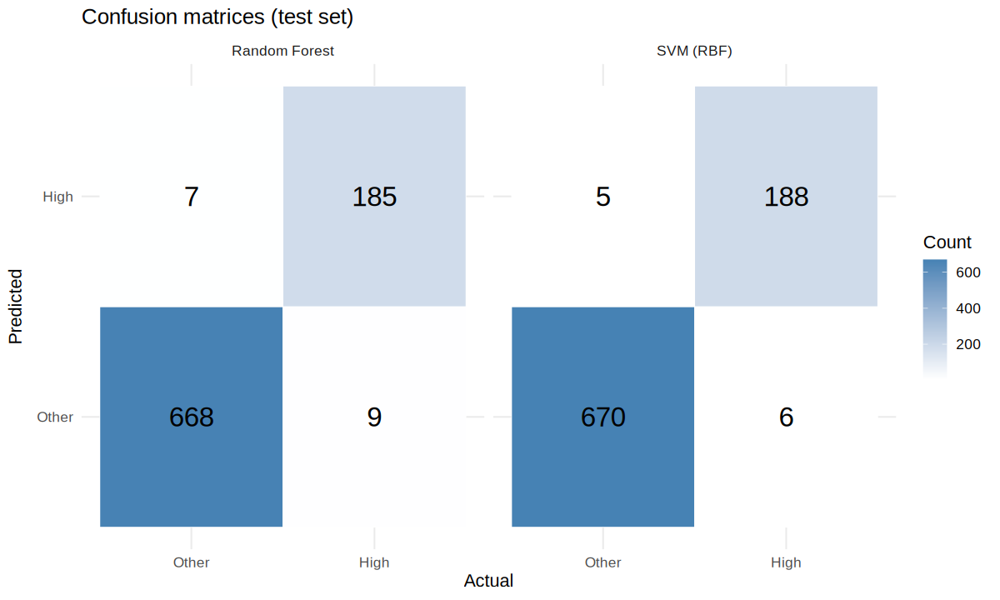

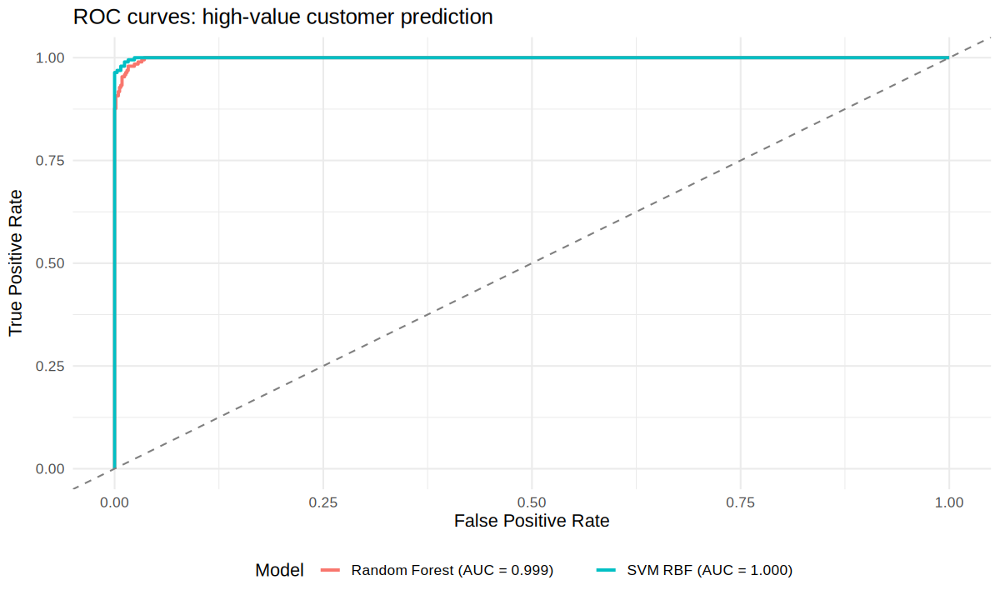

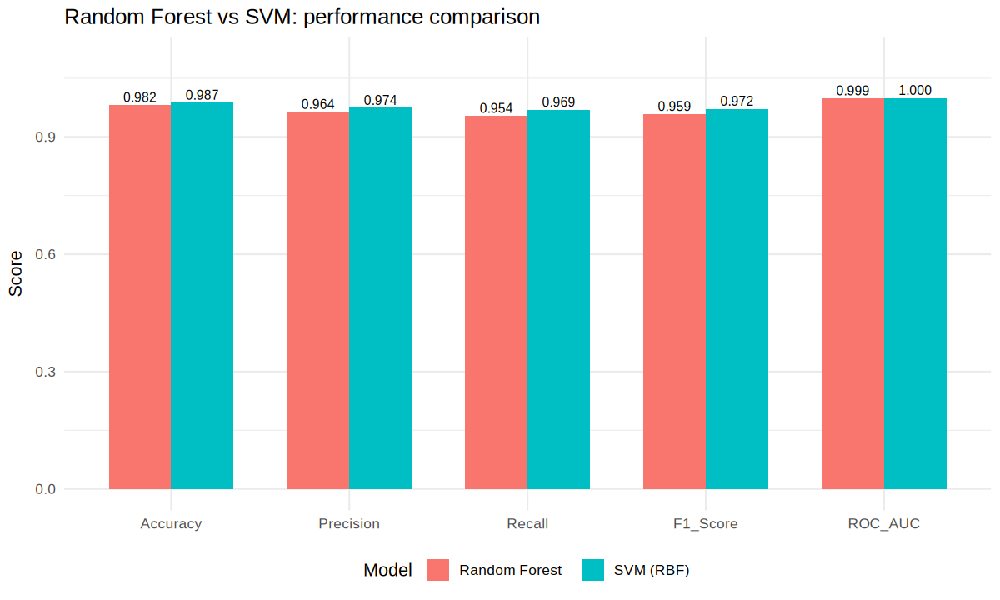

In [20]:
# ---- Confusion matrix heat-maps ----
cm_df <- rbind(
  cbind(as.data.frame(res_rf$cm),  Model = "Random Forest"),
  cbind(as.data.frame(res_svm$cm), Model = "SVM (RBF)")
)
ggplot(cm_df, aes(Actual, Predicted, fill = Freq)) +
  geom_tile(colour = "white") +
  geom_text(aes(label = Freq), size = 7) +
  scale_fill_gradient(low = "white", high = "steelblue") +
  facet_wrap(~Model) +
  labs(title = "Confusion matrices (test set)", fill = "Count")

# ---- ROC curves ----
roc_df <- function(truth, score, name) {
  ord <- order(score, decreasing = TRUE)
  y <- as.numeric(truth[ord] == "High")
  data.frame(FPR = c(0, cumsum(1 - y) / sum(1 - y)), TPR = c(0, cumsum(y) / sum(y)), Model = name)
}
roc_all <- rbind(
  roc_df(test_y, rf_prob,  sprintf("Random Forest (AUC = %.3f)", res_rf$metrics$ROC_AUC)),
  roc_df(test_y, svm_prob, sprintf("SVM RBF (AUC = %.3f)", res_svm$metrics$ROC_AUC))
)
ggplot(roc_all, aes(FPR, TPR, colour = Model)) +
  geom_line(linewidth = 1.1) +
  geom_abline(linetype = "dashed", colour = "grey50") +
  labs(title = "ROC curves: high-value customer prediction", x = "False Positive Rate", y = "True Positive Rate") +
  theme(legend.position = "bottom")

# ---- Metric comparison bar chart ----
m_long <- data.frame(
  Model  = rep(metrics_tbl$Model, times = 5),
  Metric = factor(rep(c("Accuracy", "Precision", "Recall", "F1_Score", "ROC_AUC"), each = nrow(metrics_tbl)),
                  levels = c("Accuracy", "Precision", "Recall", "F1_Score", "ROC_AUC")),
  Value  = unname(unlist(metrics_tbl[, c("Accuracy", "Precision", "Recall", "F1_Score", "ROC_AUC")]))
)
ggplot(m_long, aes(Metric, Value, fill = Model)) +
  geom_col(position = "dodge", width = 0.7) +
  geom_text(aes(label = sprintf("%.3f", Value)), position = position_dodge(width = 0.7), vjust = -0.3, size = 3.3) +
  coord_cartesian(ylim = c(0, 1.1)) +
  labs(title = "Random Forest vs SVM: performance comparison", y = "Score", x = NULL) +
  theme(legend.position = "bottom")

## 20. Feature Importance Analysis

Random Forest feature importance:
             Feature MeanDecreaseGini MeanDecreaseAccuracy
           Frequency          353.910               44.483
            Monetary          235.276               33.660
   PurchaseFrequency          211.395               58.138
       TotalQuantity          176.197               33.327
             Recency          126.060               66.576
          TenureDays           32.248               22.069
      UniqueProducts           29.596               14.413
 AvgTransactionValue           24.673               19.509
         CancelCount            9.995                9.215


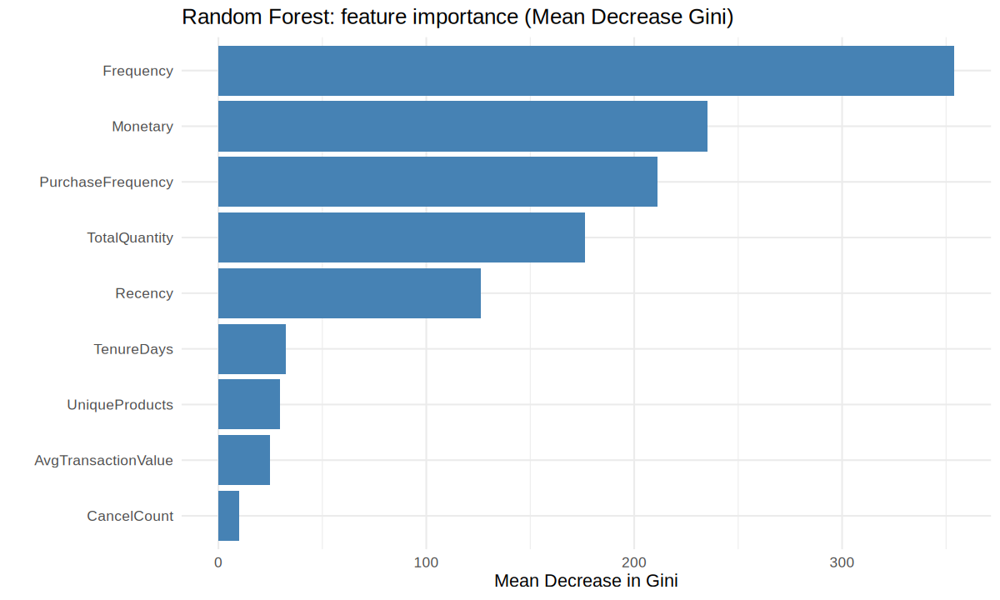

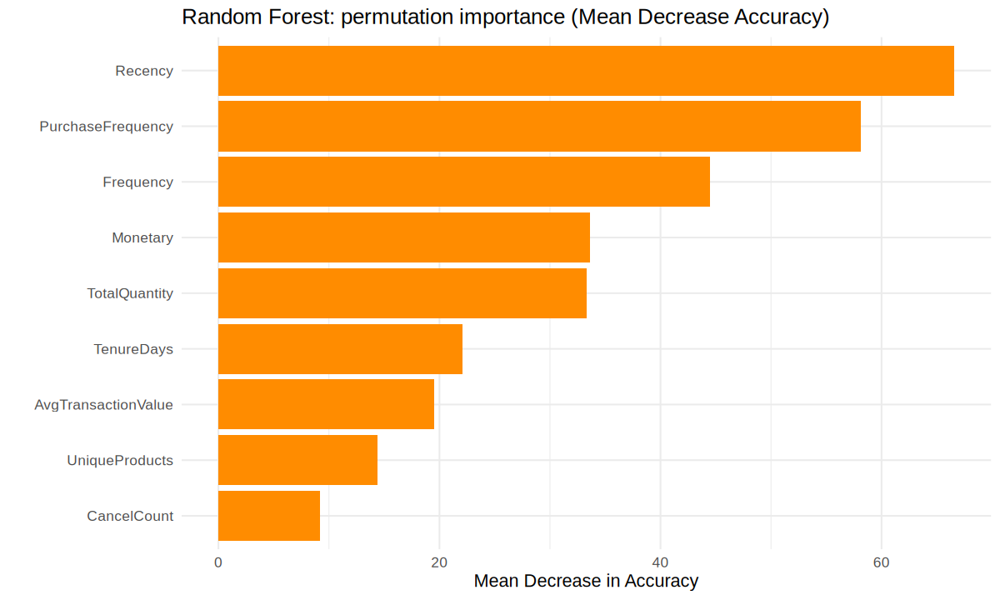

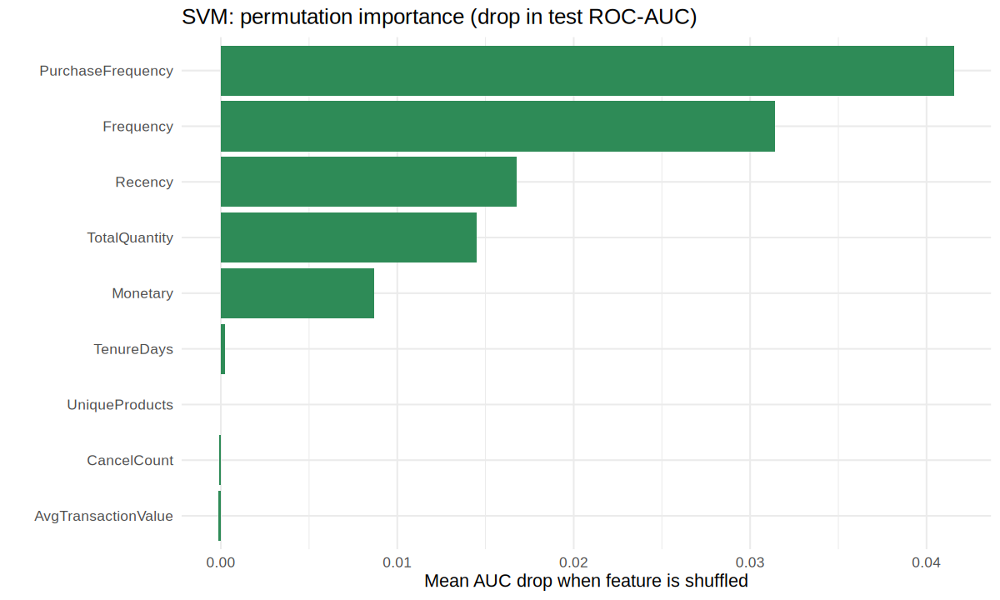

In [21]:
# ---- Random Forest importance (Gini and permutation-based accuracy) ----
imp <- as.data.frame(randomForest::importance(rf_model))
imp$Feature <- rownames(imp)
imp <- imp[order(-imp$MeanDecreaseGini), ]
cat("Random Forest feature importance:\n")
print(data.frame(Feature = imp$Feature,
                 MeanDecreaseGini = round(imp$MeanDecreaseGini, 3),
                 MeanDecreaseAccuracy = round(imp$MeanDecreaseAccuracy, 3)), row.names = FALSE)

ggplot(imp, aes(x = reorder(Feature, MeanDecreaseGini), y = MeanDecreaseGini)) +
  geom_col(fill = "steelblue") + coord_flip() +
  labs(title = "Random Forest: feature importance (Mean Decrease Gini)", x = NULL, y = "Mean Decrease in Gini")

ggplot(imp, aes(x = reorder(Feature, MeanDecreaseAccuracy), y = MeanDecreaseAccuracy)) +
  geom_col(fill = "darkorange") + coord_flip() +
  labs(title = "Random Forest: permutation importance (Mean Decrease Accuracy)", x = NULL, y = "Mean Decrease in Accuracy")

# ---- Model-agnostic permutation importance for the SVM (drop in test AUC) ----
set.seed(123)
base_auc <- res_svm$metrics$ROC_AUC
svm_imp <- sapply(names(test_x), function(f) {
  drops <- replicate(5, {
    tmp <- test_x
    tmp[[f]] <- sample(tmp[[f]])
    p <- attr(predict(svm_model, tmp, probability = TRUE), "probabilities")[, "High"]
    base_auc - auc_score(test_y, p)
  })
  mean(drops)
})
svm_imp_df <- data.frame(Feature = names(svm_imp), AUC_Drop = as.numeric(svm_imp))
svm_imp_df <- svm_imp_df[order(-svm_imp_df$AUC_Drop), ]
ggplot(svm_imp_df, aes(x = reorder(Feature, AUC_Drop), y = AUC_Drop)) +
  geom_col(fill = "seagreen") + coord_flip() +
  labs(title = "SVM: permutation importance (drop in test ROC-AUC)", x = NULL, y = "Mean AUC drop when feature is shuffled")

## 21. Segment-wise Targeted Marketing Recommendations

In [22]:
strategy_lookup <- c(
  "Champions (High-Value)" = paste(
    "Protect and reward. Launch a VIP / loyalty-tier programme with early access to new products,",
    "exclusive bundles and premium (free-shipping) service; request reviews and referrals;",
    "avoid heavy discounting because these customers already buy at full price."),
  "Potential Loyalists" = paste(
    "Grow and convert. Use personalised cross-sell and up-sell recommendations, bundle offers and",
    "volume-based incentives (e.g. 'spend X, get Y'); send replenishment reminders to raise order",
    "frequency and move them towards the Champions tier."),
  "At-Risk Customers" = paste(
    "Re-engage quickly. Send win-back campaigns with time-limited, personalised offers and",
    "'we miss you' emails; run short surveys to understand why activity dropped;",
    "highlight new arrivals in the categories they bought before."),
  "Lost / Low-Value" = paste(
    "Low-cost, automated outreach only. Use occasional low-cost email or social re-activation campaigns,",
    "clearance promotions and first-order-style incentives; do not spend heavily on acquisition-level discounts;",
    "stop contacting if there is no response after a few attempts.")
)

reco <- data.frame(
  Segment = prof$Segment,
  Customers = prof$Customers,
  Pct_Customers = round(prof$Pct_Customers, 1),
  Pct_Revenue = round(prof$Pct_Revenue, 1),
  Avg_Recency_Days = round(prof$Avg_Recency, 1),
  Avg_Orders = round(prof$Avg_Frequency, 1),
  Avg_Spend = round(prof$Avg_Monetary, 2),
  stringsAsFactors = FALSE
)
print(reco, row.names = FALSE)

cat("\n================ TARGETED MARKETING STRATEGY BY SEGMENT ================\n")
for (i in seq_len(nrow(prof))) {
  cat("\n>>", prof$Segment[i], "\n")
  cat(sprintf("   Profile : %d customers (%.1f%%), %.1f%% of revenue | avg recency %.0f days | avg %.1f orders | avg spend %.0f\n",
              prof$Customers[i], prof$Pct_Customers[i], prof$Pct_Revenue[i],
              prof$Avg_Recency[i], prof$Avg_Frequency[i], prof$Avg_Monetary[i]))
  cat("   Strategy:", strategy_lookup[[prof$Segment_Type[i]]], "\n")
}

                     Segment Customers Pct_Customers Pct_Revenue
 Champions (High-Value) [C2]       966          22.3        71.1
    Potential Loyalists [C1]      1841          42.4        24.6
       Lost / Low-Value [C3]      1531          35.3         4.3
 Avg_Recency_Days Avg_Orders Avg_Spend
             18.1       11.5   6539.56
             74.6        2.8   1189.28
            162.6        1.5    248.55

================ TARGETED MARKETING STRATEGY BY SEGMENT ================

>> Champions (High-Value) [C2] 
   Profile : 966 customers (22.3%), 71.1% of revenue | avg recency 18 days | avg 11.5 orders | avg spend 6540
   Strategy: Protect and reward. Launch a VIP / loyalty-tier programme with early access to new products, exclusive bundles and premium (free-shipping) service; request reviews and referrals; avoid heavy discounting because these customers already buy at full price. 

>> Potential Loyalists [C1] 
   Profile : 1841 customers (42.4%), 24.6% of revenue | avg recency 7

## 22. Interpretation of Results

In [23]:
best_model <- metrics_tbl$Model[which.max(metrics_tbl$F1_Score)]
top_feat   <- head(imp$Feature, 3)

cat("================ SUMMARY OF RESULTS ================\n")
cat(sprintf("Data source                      : %s\n", data_source))
cat(sprintf("Customers analysed               : %d\n", nrow(customers)))
cat(sprintf("Optimal k (elbow / silhouette)   : %d / %d  -> k used = %d\n", k_elbow, k_sil, k_final))
cat(sprintf("Silhouette: K-Means = %.3f | Hierarchical = %.3f | ARI = %.3f\n", avg_sil_km, avg_sil_hc, ari))
cat(sprintf("PCA: PC1+PC2 explain %.1f%% of variance (PC1-PC3: %.1f%%)\n", 100 * sum(var_exp[1:2]), 100 * sum(var_exp[1:3])))
cat(sprintf("High-value segment               : %s (%.1f%% of customers, %.1f%% of revenue)\n",
            hv_name, prof$Pct_Customers[1], prof$Pct_Revenue[1]))
cat("\nClassification results (test set):\n"); print(metrics_print, row.names = FALSE)
cat(sprintf("\nBest model by F1-score           : %s\n", best_model))
cat(sprintf("Top 3 predictive features (RF)   : %s\n", paste(top_feat, collapse = ", ")))

================ SUMMARY OF RESULTS ================
Data source                      : UCI Online Retail (real data)
Customers analysed               : 4338
Optimal k (elbow / silhouette)   : 3 / 2  -> k used = 3
Silhouette: K-Means = 0.259 | Hierarchical = 0.221 | ARI = 0.423
PCA: PC1+PC2 explain 84.5% of variance (PC1-PC3: 93.6%)
High-value segment               : Champions (High-Value) [C2] (22.3% of customers, 71.1% of revenue)

Classification results (test set):
         Model Accuracy Precision Recall F1_Score ROC_AUC
 Random Forest   0.9816    0.9635 0.9536   0.9585  0.9986
     SVM (RBF)   0.9873    0.9741 0.9691   0.9716  0.9996

Best model by F1-score           : SVM (RBF)
Top 3 predictive features (RF)   : Frequency, Monetary, PurchaseFrequency


In [24]:
# ---- Save outputs (download from the Files panel on the left, then add them to your Git repository) ----
write.csv(customers, "customer_segments.csv", row.names = FALSE)
write.csv(metrics_tbl, "model_performance.csv", row.names = FALSE)
cat("Saved: customer_segments.csv, model_performance.csv, plotly_pca_3d.html, plotly_rfm_3d.html\n")
sessionInfo()

Saved: customer_segments.csv, model_performance.csv, plotly_pca_3d.html, plotly_rfm_3d.html


R version 4.6.1 (2026-06-24)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 24.04.5 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.26.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] ggplot2_4.0.3 dplyr_1.2.1  

loaded via a namespace (and not attached):
 [1] plotly_4.12.1        generics_0.1.4       tidyr_1.3.2         
 [4] class_7.3-24         digest_0.